# 📘 Clase 3 · Notebook 2 — Caminata aleatoria, estacionariedad y autocorrelación

**Curso de Machine Learning · Time Series Forecasting**
Basado en *Time Series Forecasting in Python* (Marco Peixeiro), **Capítulo 3**.

| | |
|---|---|
| **Datos** | `GOOGL.csv` — precio de cierre diario de Alphabet (Google), abr-2020 a abr-2021; además, series **simuladas** |
| **Tiempo estimado en casa** | 30–40 min |
| **¿Se vio en clase?** | ✅ Parcialmente — **Demo 2** (Bloque 1): celdas de simulación, ADF, ACF y GOOGL |

### 🎯 Al terminar este notebook podrás…
1. Explicar qué es una **caminata aleatoria** y por qué engaña al ojo.
2. Definir **estacionariedad** y comprobarla con la prueba **ADF** (Dickey-Fuller aumentada).
3. Leer un gráfico de **autocorrelación (ACF)**.
4. Usar la **diferenciación** para volver estacionaria una serie.
5. Entender por qué una caminata aleatoria solo admite pronósticos ingenuos.

---

### ▶️ Cómo ejecutarlo

**En tu computador:** abre este notebook **desde su propia carpeta** (`CH03/`). Los datos se leen con la ruta relativa `../data/…`, así que si lo mueves de carpeta la lectura fallará.

**En Google Colab:** crea una celda al inicio y ejecuta:
```python
!git clone https://github.com/juandata-dev/TimeSeriesForecastingInPython.git
%cd TimeSeriesForecastingInPython/CH03
```

**Librerías:** `pandas`, `numpy`, `matplotlib`, `statsmodels`, `scikit-learn`, `tqdm`.
Si te falta alguna: `pip install statsmodels scikit-learn tqdm`.

### 🗺️ Leyenda de las anotaciones
| Ícono | Significa |
|---|---|
| 🧭 | Qué hace la siguiente celda |
| 🔎 | Cómo leer el resultado que acabas de obtener |
| 💡 | Intuición o analogía para entender el concepto |
| ⚠️ | Cuidado: error común o trampa |
| 🛠️ | Cambio que hicimos al código original del libro para que funcione con versiones recientes de las librerías |
| 🤔 | Pregunta para pensar antes de seguir |

> Las celdas en inglés con `#` son los títulos originales del libro. Las anotaciones en español son de la clase.


## 0. Librerías
🧭 Las piezas nuevas son `adfuller` (prueba de estacionariedad ADF) y `plot_acf` (gráfico de autocorrelación). `seasonal_decompose` y `STL` se importan pero en este notebook no se usan.

In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## GOOGL - April 28, 2020 to April 27, 2021

🧭 Cargamos el precio diario de cierre de Google durante un año.

🤔 ¿Crees que se puede predecir el precio de mañana con los precios anteriores?

In [4]:
df = pd.read_csv('../data/GOOGL.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-04-27,1292.000000,1294.099976,1265.060059,1270.859985,1270.859985,2209300
1,2020-04-28,1283.199951,1284.760010,1230.380005,1232.589966,1232.589966,4035000
2,2020-04-29,1345.000000,1360.150024,1326.729980,1342.180054,1342.180054,5417900
3,2020-04-30,1331.359985,1350.000000,1321.500000,1346.699951,1346.699951,2792100
4,2020-05-01,1324.089966,1351.430054,1309.660034,1317.319946,1317.319946,2443600


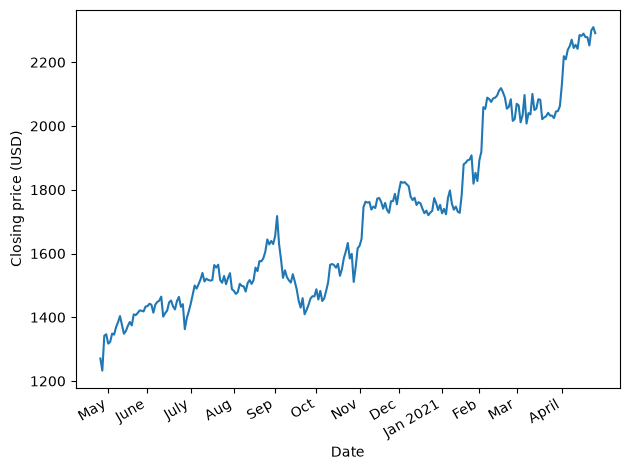

In [5]:
fig, ax = plt.subplots()

ax.plot(df['Date'], df['Close'])
ax.set_xlabel('Date')
ax.set_ylabel('Closing price (USD)')

plt.xticks(
    [4, 24, 46, 68, 89, 110, 132, 152, 174, 193, 212, 235], 
    ['May', 'June', 'July', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan 2021', 'Feb', 'Mar', 'April'])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH03_F01_peixeiro.png', dpi=300)

🔎 Subidas y bajadas sin un patrón claro. Guarda esta imagen: en unos minutos veremos que se comporta como una caminata aleatoria.

## 3.1 The random walk process 

💡 **Caminata aleatoria (*random walk*)**

$$y_t = y_{t-1} + \varepsilon_t, \qquad \varepsilon_t \sim \text{ruido blanco}$$

Analogía: una persona que da un paso al azar (adelante o atrás) cada segundo. Su posición hoy = su posición anterior + un paso aleatorio. No hay patrón: solo azar acumulado.

🧭 En código: generamos 1000 pasos aleatorios normales y los **sumamos acumuladamente** con `np.cumsum`. `np.random.seed(42)` fija el azar para que todos obtengamos la misma serie.

In [6]:
np.random.seed(42)

steps = np.random.standard_normal(1000)
steps[0]=0

random_walk = np.cumsum(steps)

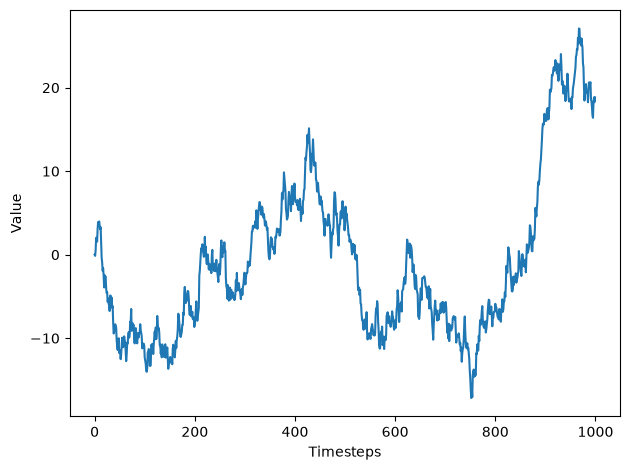

In [7]:
fig, ax = plt.subplots()

ax.plot(random_walk)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

plt.tight_layout()
plt.savefig('figures/CH03_F03_peixeiro.png', dpi=300)

🔎 ¡Es puro azar y sin embargo **parece** tener tendencias! **Lección:** el ojo humano encuentra patrones donde no los hay. Por eso necesitamos pruebas estadísticas.

### 3.2.2 Testing for stationarity 

💡 **Estacionariedad.** Una serie es **estacionaria** si su **media, su varianza y su autocorrelación no cambian con el tiempo**.

Analogía: la temperatura de una ciudad ecuatorial (oscila alrededor del mismo promedio siempre) vs. la temperatura de un café que se enfría (su media cambia todo el tiempo).

¿Por qué importa? Los modelos AR, MA y ARMA **asumen** estacionariedad: aprenden reglas del pasado que deben seguir valiendo en el futuro.

🧭 Simulamos $y_t = \alpha\,y_{t-1} + \varepsilon_t$ dos veces: con $\alpha = 0.5$ (estacionaria) y con $\alpha = 1$ (caminata aleatoria, no estacionaria).

In [8]:
def simulate_process(is_stationary: bool) -> np.array:
    np.random.seed(42)
    process = np.empty(400)
    
    if is_stationary:
        alpha = 0.5
        process[0] = 0
    else:
        alpha = 1
        process[0] = 10
        
    for i in range(400):
        if i+1 < 400:
            process[i+1] = alpha*process[i] + np.random.standard_normal()
        else:
            break
        
    return process

In [9]:
stationary = simulate_process(True)
non_stationary = simulate_process(False)

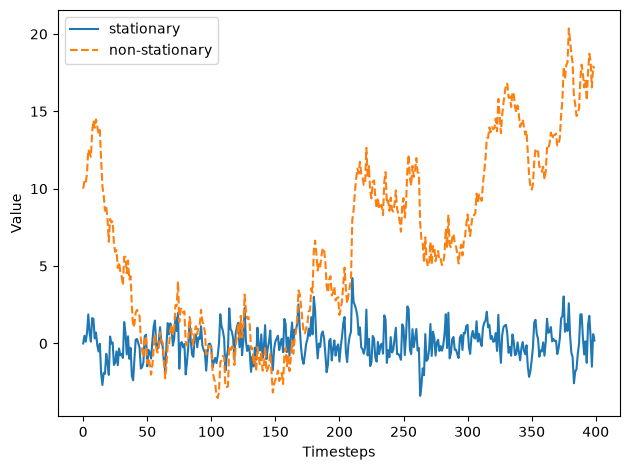

In [10]:
fig, ax = plt.subplots()

ax.plot(stationary, linestyle='-', label='stationary')
ax.plot(non_stationary, linestyle='--', label='non-stationary')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')
ax.legend(loc=2)

plt.tight_layout()
plt.savefig('figures/CH03_F06_peixeiro.png', dpi=300)

🔎 La serie estacionaria (línea continua) oscila alrededor de 0. La no estacionaria (discontinua) deambula sin volver a ningún nivel fijo.

🧭 Calculamos la **media acumulada**: el promedio de los primeros *i* puntos, para cada *i*. Si la serie es estacionaria, esa media debería estabilizarse.

In [11]:
def mean_over_time(process: np.array) -> np.array:
    mean_func = []
    
    for i in range(len(process)):
        mean_func.append(np.mean(process[:i]))
    
    return mean_func

In [12]:
stationary_mean = mean_over_time(stationary)
non_stationary_mean = mean_over_time(non_stationary)

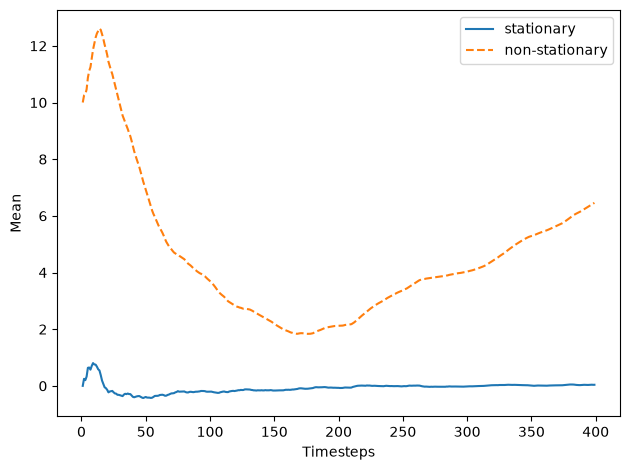

In [13]:
fig, ax = plt.subplots()

ax.plot(stationary_mean, label='stationary')
ax.plot(non_stationary_mean, linestyle='--', label='non-stationary')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Mean')
ax.legend(loc=1)

plt.tight_layout()
plt.savefig('figures/CH03_F07_peixeiro.png', dpi=300)

🔎 La media de la estacionaria se estabiliza cerca de 0; la de la no estacionaria sigue cambiando.

🧭 Lo mismo con la **varianza acumulada**.

In [14]:
def var_over_time(process: np.array) -> np.array:
    var_func = []
    
    for i in range(len(process)):
        var_func.append(np.var(process[:i]))
    
    return var_func

In [15]:
stationary_var = var_over_time(stationary)
non_stationary_var = var_over_time(non_stationary)

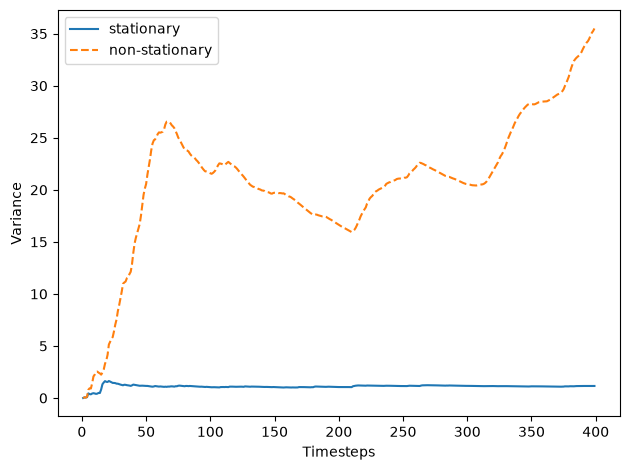

In [16]:
fig, ax = plt.subplots()

ax.plot(stationary_var, label='stationary')
ax.plot(non_stationary_var, linestyle='--', label='non-stationary')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Variance')
ax.legend(loc=2)

plt.tight_layout()
plt.savefig('figures/CH03_F08_peixeiro.png', dpi=300)

🔎 Igual con la varianza: estable en una, creciente en la otra. Eso es exactamente lo que significa *no estacionaria*.

### 3.2.4 Putting it all together 

💡 **Prueba ADF (Augmented Dickey-Fuller).**
- **H0:** la serie tiene *raíz unitaria* → **NO es estacionaria**.
- Si **p-valor < 0.05** → rechazamos H0 → la serie **es estacionaria**.
- El estadístico ADF: mientras **más negativo**, más evidencia de estacionariedad.

Regla nemotécnica: *“p-valor pequeño = serie tranquila (estacionaria)”*.

In [17]:
ADF_result = adfuller(random_walk)

print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -0.9659524876918755
p-value: 0.7654789696692579


🔎 p-valor ≈ 0.77 > 0.05 → **no** rechazamos H0 → la caminata aleatoria **no es estacionaria** (lo esperado).

💡 **Función de autocorrelación (ACF).** Mide la correlación entre la serie y **ella misma desplazada *k* pasos** (el rezago o *lag* *k*). Pregunta: *¿cuánto se parece hoy a ayer? ¿y a anteayer?*
- La barra del lag 0 siempre vale 1 (la serie se parece perfecto a sí misma).
- La **zona sombreada** es el intervalo de confianza: barras dentro de ella no son significativas (pueden ser azar).

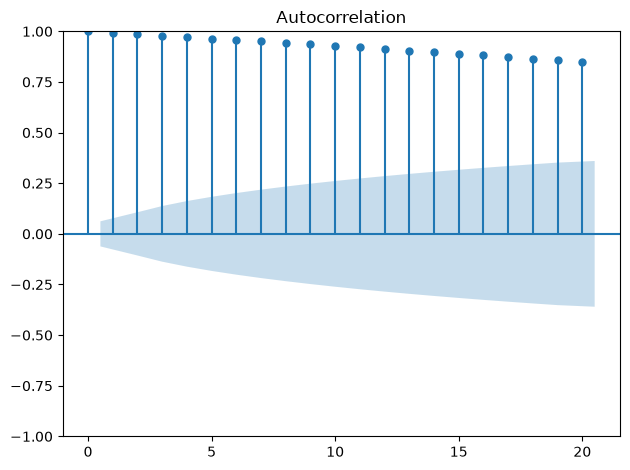

In [18]:
plot_acf(random_walk, lags=20);

plt.tight_layout()
plt.savefig('figures/CH03_F09_peixeiro.png', dpi=300)

🔎 La ACF **decae lentamente**: cada valor se parece mucho al anterior. Esta es la firma típica de una serie **con tendencia / no estacionaria**.

💡 **Diferenciación.** Transformamos *niveles* en *cambios*: $y'_t = y_t - y_{t-1}$. En una caminata aleatoria, la diferencia es exactamente el paso aleatorio $\varepsilon_t$.

⚠️ `np.diff` devuelve una serie con **un punto menos** (el primer valor no tiene anterior).

In [19]:
diff_random_walk = np.diff(random_walk, n=1)

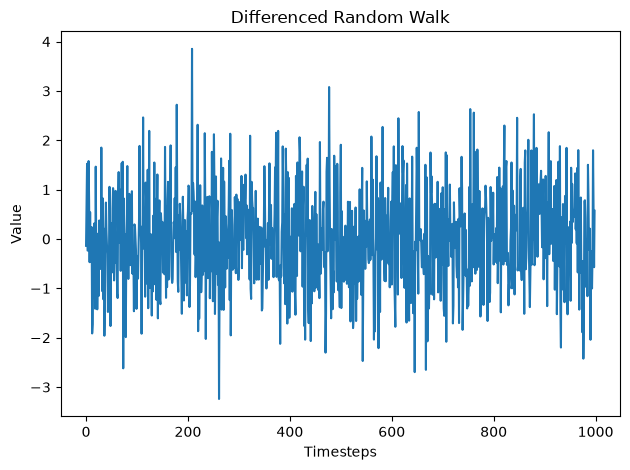

In [20]:
plt.plot(diff_random_walk)
plt.title('Differenced Random Walk')
plt.xlabel('Timesteps')
plt.ylabel('Value')
plt.tight_layout()

plt.savefig('figures/CH03_F10_peixeiro.png', dpi=300)

In [21]:
ADF_result = adfuller(diff_random_walk)

print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -31.789310857560594
p-value: 0.0


🔎 p-valor ≈ 0 → la serie diferenciada **sí es estacionaria**.

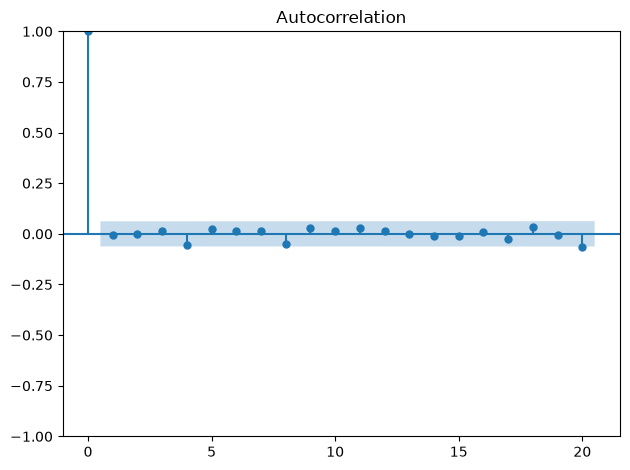

In [22]:
plot_acf(diff_random_walk, lags=20);

plt.tight_layout()

plt.savefig('figures/CH03_F11_peixeiro.png', dpi=300)

🔎 Ninguna barra significativa después del lag 0 → la serie diferenciada es **ruido blanco**.

✅ **Conclusión:** una serie que (1) no es estacionaria, (2) se vuelve estacionaria al diferenciar y (3) cuya diferencia no tiene autocorrelación, **es una caminata aleatoria**.

Procedimiento: `ADF` → *¿no estacionaria?* → diferenciar → `ADF` → `ACF` → *¿sin autocorrelación?* → caminata aleatoria.

### 3.2.5 Is GOOGL a random walk? 

🧭 Aplicamos **el mismo procedimiento** a los precios reales de Google: ADF → diferenciar → ADF → ACF.

In [23]:
GOOGL_ADF_result = adfuller(df['Close'])

print(f'ADF Statistic: {GOOGL_ADF_result[0]}')
print(f'p-value: {GOOGL_ADF_result[1]}')

ADF Statistic: 0.16025048664771283
p-value: 0.9699419435913057


In [24]:
diff_close = np.diff(df['Close'], n=1)

In [25]:
GOOGL_diff_ADF_result = adfuller(diff_close)

print(f'ADF Statistic: {GOOGL_diff_ADF_result[0]}')
print(f'p-value: {GOOGL_diff_ADF_result[1]}')

ADF Statistic: -5.303439704295231
p-value: 5.386530961454658e-06


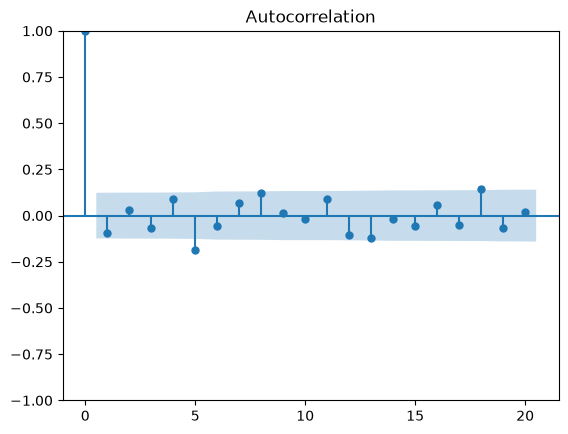

In [26]:
plot_acf(diff_close, lags=20);

plt.savefig('figures/CH03_F13_peixeiro.png', dpi=300)

🔎 Los precios de GOOGL: no estacionarios (p ≈ 0.97); diferenciados sí (p ≈ 0.000005); y la ACF de las diferencias casi no tiene barras significativas. → **En este período, GOOGL se comporta como una caminata aleatoria.**

💡 Implicación práctica: si los cambios diarios son azar puro, ningún modelo estadístico hará mucho mejor que *“mañana = hoy”*.

## 3.3 Forecasting a random walk
### 3.3.1 Forecasting on a long horizon

🧭 Ahora intentamos **pronosticar** la caminata simulada: los primeros 800 puntos son `train` y los últimos 200 son `test`.

In [27]:
df = pd.DataFrame({'value': random_walk})

train = df[:800]
test = df[800:]

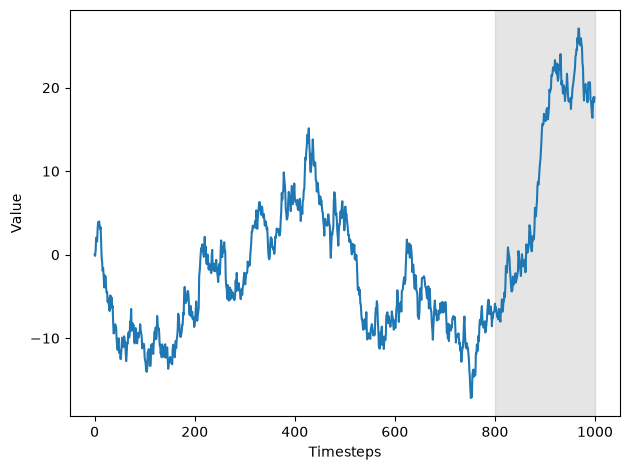

In [28]:
fig, ax = plt.subplots()

ax.plot(random_walk)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')
ax.axvspan(800, 1000, color='#808080', alpha=0.2)

plt.tight_layout()
plt.savefig('figures/CH03_F14_peixeiro.png', dpi=300)

💡 Baseline 1: **media** del train.

In [29]:
mean = np.mean(train.value)

test.loc[:, 'pred_mean'] = mean

test.head()

,value,pred_mean
800,-5.876664,-3.677206
801,-6.392708,-3.677206
802,-6.296588,-3.677206
803,-6.758863,-3.677206
804,-7.193359,-3.677206


💡 Baseline 2: **último valor** conocido.

In [30]:
last_value = train.iloc[-1].value

test.loc[:, 'pred_last'] = last_value

test.head()

,value,pred_mean,pred_last
800,-5.876664,-3.677206,-6.814947
801,-6.392708,-3.677206,-6.814947
802,-6.296588,-3.677206,-6.814947
803,-6.758863,-3.677206,-6.814947
804,-7.193359,-3.677206,-6.814947


💡 Baseline 3: **deriva (*drift*)**: trazamos una recta entre el primer y el último punto del train y la prolongamos. Pendiente = (último − primero) / (n − 1).

In [31]:
deltaX = 800 - 1
deltaY = last_value - 0

drift = deltaY / deltaX

x_vals = np.arange(801, 1001, 1)

pred_drift = drift * x_vals

test.loc[:, 'pred_drift'] = pred_drift

test.head()

,value,pred_mean,pred_last,pred_drift
800,-5.876664,-3.677206,-6.814947,-6.832006
801,-6.392708,-3.677206,-6.814947,-6.840536
802,-6.296588,-3.677206,-6.814947,-6.849065
803,-6.758863,-3.677206,-6.814947,-6.857594
804,-7.193359,-3.677206,-6.814947,-6.866124


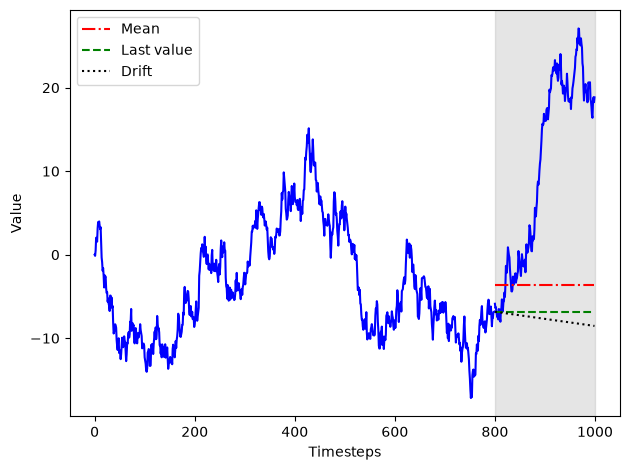

In [32]:
fig, ax = plt.subplots()

ax.plot(train.value, 'b-')
ax.plot(test['value'], 'b-')
ax.plot(test['pred_mean'], 'r-.', label='Mean')
ax.plot(test['pred_last'], 'g--', label='Last value')
ax.plot(test['pred_drift'], 'k:', label='Drift')

ax.axvspan(800, 1000, color='#808080', alpha=0.2)
ax.legend(loc=2)

ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

plt.tight_layout()
plt.savefig('figures/CH03_F15_peixeiro.png', dpi=300)

In [33]:
from sklearn.metrics import mean_squared_error

mse_mean = mean_squared_error(test['value'], test['pred_mean'])
mse_last = mean_squared_error(test['value'], test['pred_last'])
mse_drift = mean_squared_error(test['value'], test['pred_drift'])

print(mse_mean, mse_last, mse_drift)

326.50277395297474 425.1726033055617 466.2172769077409


🔎 MSE: media ≈ 327, último valor ≈ 425, deriva ≈ 466. **Todos son malos**: pronosticar 200 pasos de azar acumulado es imposible.

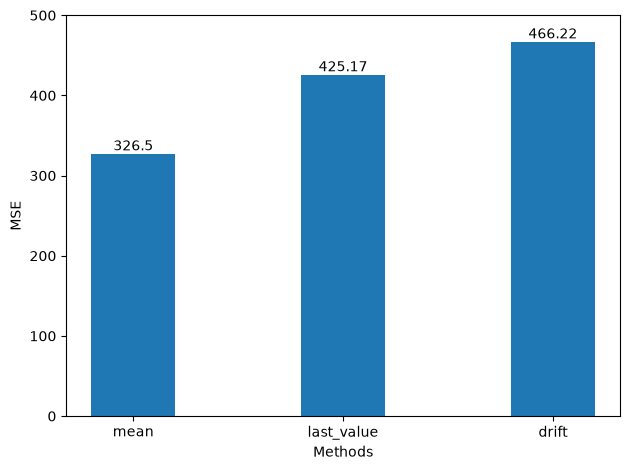

In [34]:
fig, ax = plt.subplots()

x = ['mean', 'last_value', 'drift']
y = [mse_mean, mse_last, mse_drift]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Methods')
ax.set_ylabel('MSE')
ax.set_ylim(0, 500)

for index, value in enumerate(y):
    plt.text(x=index, y=value+5, s=str(round(value, 2)), ha='center')

plt.tight_layout()

plt.savefig('figures/CH03_F16_peixeiro.png', dpi=300)

### 3.3.2 Forecasting the next timestep 

💡 ¿Y si solo pronosticamos **el siguiente paso**? La mejor apuesta es “mañana = hoy”. `df.shift(1)` desplaza la serie un paso: el valor de ayer se convierte en el pronóstico de hoy.

In [35]:
df_shift = df.shift(periods=1)

df_shift.head()

,value
0,NaN
1,0.000000
2,-0.138264
3,0.509424
4,2.032454


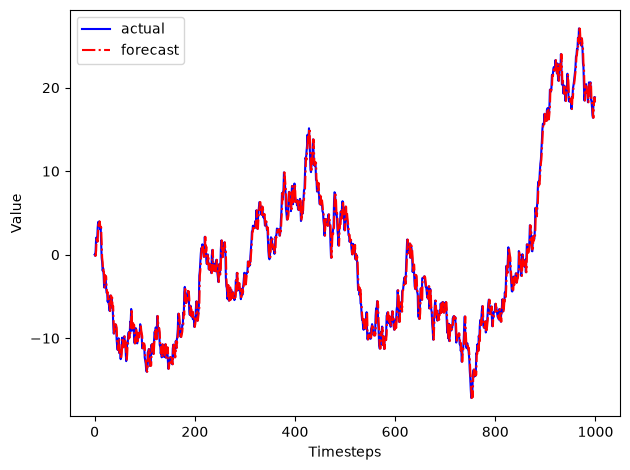

In [36]:
fig, ax = plt.subplots()

ax.plot(df, 'b-', label='actual')
ax.plot(df_shift, 'r-.', label='forecast')

ax.legend(loc=2)

ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

plt.tight_layout()

plt.savefig('figures/CH03_F18_peixeiro.png', dpi=300)

In [37]:
mse_one_step = mean_squared_error(test['value'], df_shift[800:])

mse_one_step

0.9256876651440581

🔎 MSE ≈ 0.93, muy cerca de la varianza del ruido (1). ¡Es casi lo mejor posible! **Lección:** con una caminata aleatoria solo tiene sentido pronosticar **un paso adelante** con el último valor.

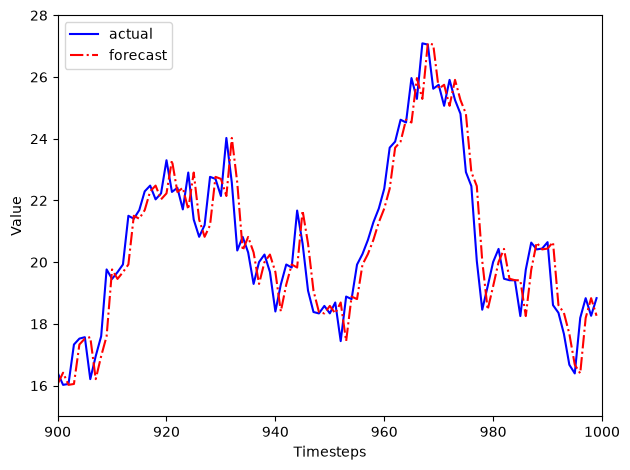

In [38]:
fig, ax = plt.subplots()

ax.plot(df, 'b-', label='actual')
ax.plot(df_shift, 'r-.', label='forecast')

ax.legend(loc=2)

ax.set_xlim(900, 1000)
ax.set_ylim(15, 28)

ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

plt.tight_layout()

plt.savefig('figures/CH03_F19_peixeiro.png', dpi=300)

---
## ✅ Resumen del notebook
- **Estacionaria** = media, varianza y autocorrelación constantes en el tiempo. Los modelos AR/MA/ARMA la necesitan.
- **ADF:** p < 0.05 → estacionaria. Si no, **diferencia** y vuelve a probar.
- **ACF:** decaimiento lento → tendencia; sin barras significativas → ruido blanco.
- **Caminata aleatoria:** solo se pronostica con métodos ingenuos, y solo a un paso.

🔗 **Siguiente paso:** ¿qué pasa si la serie diferenciada **sí** tiene autocorrelación? Entonces hay estructura que modelar → modelos **MA** (Capítulo 4) y **AR** (Capítulo 5).

### 🏠 Ejercicios para casa
Abre `CH03_exercises_solution.ipynb` e intenta resolverlos **antes** de mirar las soluciones:
1. Simula tu propia caminata aleatoria con otra semilla y repite el procedimiento completo.
2. Aplica el procedimiento a otra acción (puedes descargar precios con `yfinance`).

### 🧠 Autoevaluación
- ¿Qué afirma la hipótesis nula de la prueba ADF?
- Si la ACF de una serie diferenciada tiene barras significativas en los lags 1 y 2, ¿es una caminata aleatoria?
